<a href="https://colab.research.google.com/github/Koelgeetkaur26/Hopfield-Network-associative-memory-analysis/blob/main/Hopfield_Network_associative_memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# ==========================================================
# Mathematical Analysis of Associative Memory in Hopfield Networks
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import random


In [22]:
# -----------------------------
# Reproducibility
# -----------------------------
np.random.seed(42)
random.seed(42)


In [23]:

# ==========================================================
# SECTION 1: CORE HOPFIELD FUNCTIONS
# ==========================================================

def generate_random_patterns(num_patterns, num_neurons):
    """
    Generate random binary patterns with values in {-1, +1}.
    Shape: (num_patterns, num_neurons)
    """
    return np.random.choice([-1, 1], size=(num_patterns, num_neurons))


def hebbian_weights(patterns, normalize_by="neurons"):
    """
    Construct Hopfield weight matrix using Hebbian learning.

    Mathematical form:
        W = (1/N) * sum_p (xi^p)(xi^p)^T
    with diagonal set to zero.

    Parameters
    ----------
    patterns : ndarray, shape (P, N)
        Stored patterns
    normalize_by : str
        "neurons"  -> divide by N (more standard for theory)
        "patterns" -> divide by P
        "none"     -> no normalization

    Returns
    -------
    W : ndarray, shape (N, N)
        Symmetric Hopfield weight matrix
    """
    P, N = patterns.shape
    W = np.zeros((N, N), dtype=float)

    for p in patterns:
        W += np.outer(p, p)

    np.fill_diagonal(W, 0.0)

    if normalize_by == "neurons":
        W /= N
    elif normalize_by == "patterns":
        W /= P
    elif normalize_by == "none":
        pass
    else:
        raise ValueError("normalize_by must be one of: 'neurons', 'patterns', 'none'")

    return W


def energy(state, W):
    """
    Hopfield energy function:
        E(s) = -1/2 * s^T W s
    """
    return -0.5 * state @ W @ state


def local_field(state, W, idx):
    """
    Local field at neuron idx:
        h_i = sum_j W_ij s_j
    """
    return np.dot(W[idx], state)


def update_neuron(state, W, idx):
    """
    Asynchronous update of a single neuron:
        s_i <- sign(h_i)
    Convention:
        if h_i >= 0, output +1
        else output -1
    """
    h_i = local_field(state, W, idx)
    return 1 if h_i >= 0 else -1


def run_network(initial_state, W, max_sweeps=20, return_energies=False):
    """
    Run asynchronous Hopfield updates until convergence or max_sweeps.

    A 'sweep' means attempting to update all neurons once in random order.

    Parameters
    ----------
    initial_state : ndarray, shape (N,)
    W : ndarray, shape (N, N)
    max_sweeps : int
    return_energies : bool

    Returns
    -------
    final_state : ndarray
    energies : list (optional)
    """
    state = initial_state.copy()
    N = len(state)
    energies = [energy(state, W)]

    for _ in range(max_sweeps):
        prev_state = state.copy()
        indices = list(range(N))
        random.shuffle(indices)

        for i in indices:
            state[i] = update_neuron(state, W, i)

        energies.append(energy(state, W))

        if np.array_equal(state, prev_state):
            break

    if return_energies:
        return state, energies
    return state


def flip_bits(pattern, flip_fraction):
    """
    Flip a fraction of bits in the pattern.
    """
    noisy = pattern.copy()
    N = len(pattern)
    n_flip = int(round(flip_fraction * N))
    n_flip = min(n_flip, N)

    if n_flip > 0:
        flip_idx = random.sample(range(N), n_flip)
        noisy[flip_idx] *= -1

    return noisy


def recall_accuracy(recalled, target):
    """
    Fraction of matching bits.
    """
    return np.mean(recalled == target)


def exact_match(recalled, target):
    """
    Whether the full pattern is recalled exactly.
    """
    return int(np.array_equal(recalled, target))



In [24]:

# ==========================================================
# SECTION 2: ENERGY MONOTONICITY CHECK
# ==========================================================

def verify_energy_monotonicity(W, test_state, num_single_updates=100):
    """
    Numerically verify that energy does not increase under asynchronous updates.
    This is not a formal proof, but a computational demonstration.

    Returns
    -------
    energies : list
    nonincreasing : bool
    """
    state = test_state.copy()
    N = len(state)
    energies = [energy(state, W)]

    for _ in range(num_single_updates):
        idx = random.randrange(N)
        state[idx] = update_neuron(state, W, idx)
        energies.append(energy(state, W))

    nonincreasing = all(
        energies[k + 1] <= energies[k] + 1e-10
        for k in range(len(energies) - 1)
    )
    return energies, nonincreasing


In [25]:

# ==========================================================
# SECTION 3: BASIN OF ATTRACTION / NOISE TOLERANCE
# ==========================================================

def basin_of_attraction_experiment(
    patterns,
    noise_levels,
    trials_per_pattern=30,
    max_sweeps=20,
    normalize_by="neurons"
):
    """
    For each noise level, measure:
    1. average bitwise recall accuracy
    2. exact full-pattern recovery probability
    """
    W = hebbian_weights(patterns, normalize_by=normalize_by)

    avg_bitwise_accuracy = []
    exact_recovery_prob = []

    for noise in noise_levels:
        bit_acc_list = []
        exact_list = []

        for p in patterns:
            for _ in range(trials_per_pattern):
                noisy = flip_bits(p, noise)
                recalled = run_network(noisy, W, max_sweeps=max_sweeps)
                bit_acc_list.append(recall_accuracy(recalled, p))
                exact_list.append(exact_match(recalled, p))

        avg_bitwise_accuracy.append(np.mean(bit_acc_list))
        exact_recovery_prob.append(np.mean(exact_list))

    return avg_bitwise_accuracy, exact_recovery_prob


In [26]:

# ==========================================================
# SECTION 4: STORAGE CAPACITY EXPERIMENT
# ==========================================================

def storage_capacity_experiment(
    num_neurons=100,
    max_patterns=30,
    noise_fraction=0.10,
    trials_per_P=20,
    max_sweeps=20,
    normalize_by="neurons"
):
    """
    Study recall performance as number of stored patterns increases.

    Classical Hopfield theory predicts approximate storage capacity:
        P_max ~ 0.138 * N
    for random dense patterns under ideal assumptions.

    Here we estimate recall performance experimentally.
    """
    pattern_counts = list(range(1, max_patterns + 1))
    exact_recall_rates = []
    bitwise_recall_rates = []

    for P in pattern_counts:
        patterns = generate_random_patterns(P, num_neurons)
        W = hebbian_weights(patterns, normalize_by=normalize_by)

        exact_list = []
        bit_list = []

        for _ in range(trials_per_P):
            idx = np.random.randint(P)
            target = patterns[idx]
            noisy = flip_bits(target, noise_fraction)
            recalled = run_network(noisy, W, max_sweeps=max_sweeps)

            exact_list.append(exact_match(recalled, target))
            bit_list.append(recall_accuracy(recalled, target))

        exact_recall_rates.append(np.mean(exact_list))
        bitwise_recall_rates.append(np.mean(bit_list))

    theoretical_capacity = 0.138 * num_neurons
    return pattern_counts, exact_recall_rates, bitwise_recall_rates, theoretical_capacity


In [27]:
# ==========================================================
# SECTION 5: SEQUENTIAL LEARNING / FORGETTING-STYLE TEST
# ==========================================================

def sequential_learning_experiment(
    all_patterns,
    test_noise=0.10,
    trials_per_step=20,
    max_sweeps=20,
    normalize_by="neurons"
):
    """
    Add patterns sequentially and test recall of the first stored pattern.

    Important note:
    Standard Hopfield networks are not usually presented as online-learning
    models in the same sense as modern neural nets, so this is not classical
    'catastrophic forgetting' in the deep-learning sense. But it does show
    interference as memory load increases.
    """
    max_patterns = len(all_patterns)
    first_pattern_exact = []
    first_pattern_bitwise = []

    for learned in range(1, max_patterns + 1):
        current_patterns = all_patterns[:learned]
        W = hebbian_weights(current_patterns, normalize_by=normalize_by)

        exact_list = []
        bit_list = []

        for _ in range(trials_per_step):
            noisy = flip_bits(all_patterns[0], test_noise)
            recalled = run_network(noisy, W, max_sweeps=max_sweeps)
            exact_list.append(exact_match(recalled, all_patterns[0]))
            bit_list.append(recall_accuracy(recalled, all_patterns[0]))

        first_pattern_exact.append(np.mean(exact_list))
        first_pattern_bitwise.append(np.mean(bit_list))

    return list(range(1, max_patterns + 1)), first_pattern_exact, first_pattern_bitwise



HOPFIELD NETWORK PROJECT: MATHEMATICAL + COMPUTATIONAL ANALYSIS
Number of neurons (N): 100
Number of stored patterns (P): 8
Theoretical rough capacity 0.138*N ≈ 13.80
Weight matrix shape: (100, 100)

Single-pattern recall example
Bitwise recall accuracy: 1.000
Exact pattern recovered: True



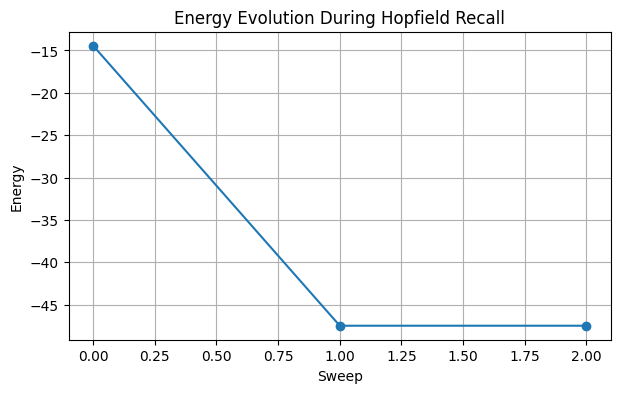

Energy monotonicity check under asynchronous updates
Energy non-increasing: True



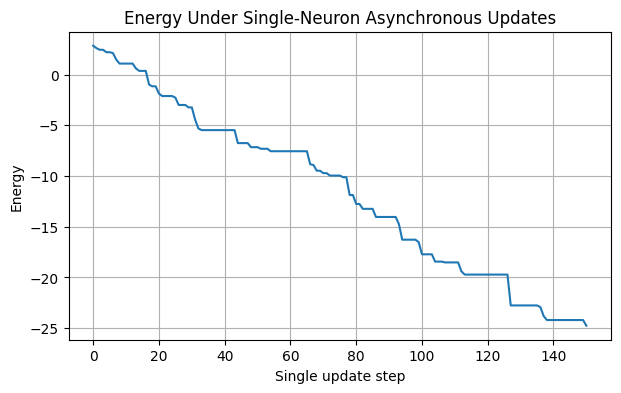

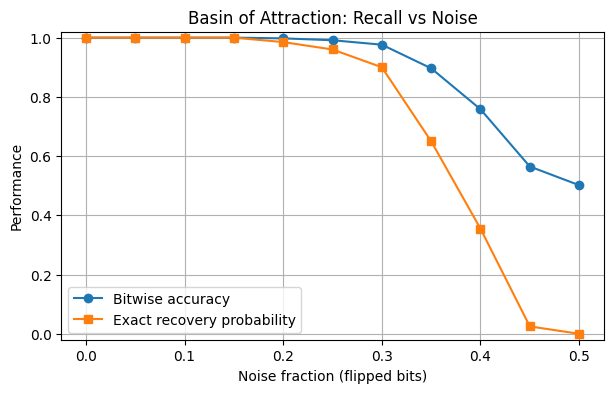

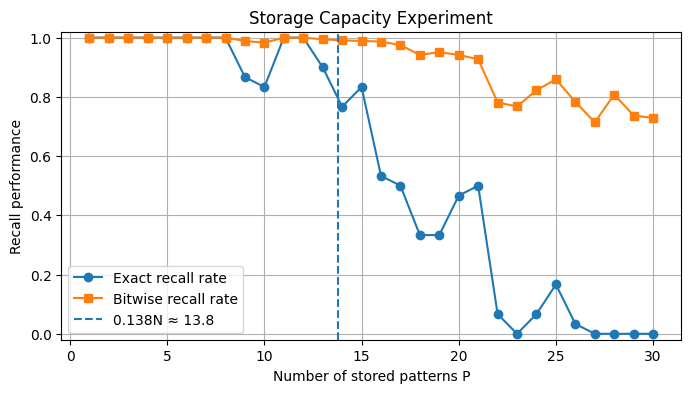

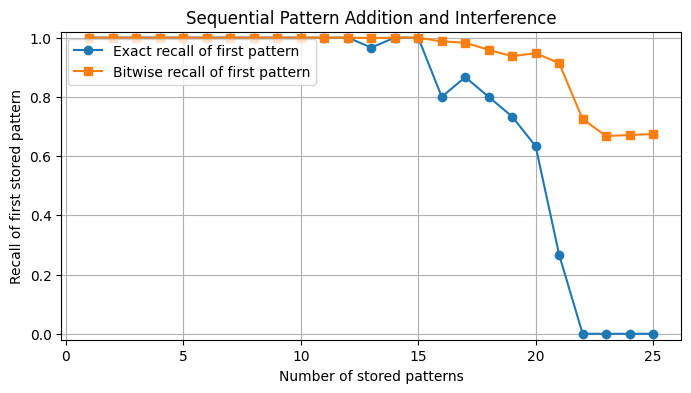

SUMMARY
1. Hopfield recall converges to low-energy states.
2. Energy was numerically verified to be non-increasing under asynchronous updates.
3. Recall performance decreases as input noise increases.
4. Recall performance also decreases as more random patterns are stored.
5. Sequential addition of patterns produces interference with earlier memories.

This makes the project stronger mathematically because it now includes:
- energy-based dynamics
- attractor analysis
- storage-capacity analysis
- computational verification of theoretical behavior


In [28]:
# ==========================================================
# SECTION 6: DEMO / MAIN ANALYSIS
# ==========================================================

def main():
    # -----------------------------
    # Basic settings
    # -----------------------------
    num_neurons = 100
    num_patterns = 8
    normalize_by = "neurons"

    print("=" * 70)
    print("HOPFIELD NETWORK PROJECT: MATHEMATICAL + COMPUTATIONAL ANALYSIS")
    print("=" * 70)

    # -----------------------------
    # Generate and train
    # -----------------------------
    patterns = generate_random_patterns(num_patterns, num_neurons)
    W = hebbian_weights(patterns, normalize_by=normalize_by)

    print(f"Number of neurons (N): {num_neurons}")
    print(f"Number of stored patterns (P): {num_patterns}")
    print(f"Theoretical rough capacity 0.138*N ≈ {0.138 * num_neurons:.2f}")
    print(f"Weight matrix shape: {W.shape}")
    print()

    # ======================================================
    # A. Recall of one noisy pattern + energy trajectory
    # ======================================================
    target = patterns[0]
    noisy = flip_bits(target, flip_fraction=0.20)
    recalled, energies = run_network(noisy, W, max_sweeps=20, return_energies=True)

    print("Single-pattern recall example")
    print(f"Bitwise recall accuracy: {recall_accuracy(recalled, target):.3f}")
    print(f"Exact pattern recovered: {bool(exact_match(recalled, target))}")
    print()

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(energies)), energies, marker='o')
    plt.title("Energy Evolution During Hopfield Recall")
    plt.xlabel("Sweep")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.show()

    # ======================================================
    # B. Energy monotonicity check
    # ======================================================
    random_state = np.random.choice([-1, 1], size=num_neurons)
    single_update_energies, nonincreasing = verify_energy_monotonicity(
        W, random_state, num_single_updates=150
    )

    print("Energy monotonicity check under asynchronous updates")
    print(f"Energy non-increasing: {nonincreasing}")
    print()

    plt.figure(figsize=(7, 4))
    plt.plot(range(len(single_update_energies)), single_update_energies)
    plt.title("Energy Under Single-Neuron Asynchronous Updates")
    plt.xlabel("Single update step")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.show()

    # ======================================================
    # C. Basin of attraction / noise tolerance
    # ======================================================
    noise_levels = np.linspace(0.0, 0.5, 11)
    avg_bitwise_acc, exact_rec_prob = basin_of_attraction_experiment(
        patterns,
        noise_levels=noise_levels,
        trials_per_pattern=25,
        max_sweeps=20,
        normalize_by=normalize_by
    )

    plt.figure(figsize=(7, 4))
    plt.plot(noise_levels, avg_bitwise_acc, marker='o', label='Bitwise accuracy')
    plt.plot(noise_levels, exact_rec_prob, marker='s', label='Exact recovery probability')
    plt.title("Basin of Attraction: Recall vs Noise")
    plt.xlabel("Noise fraction (flipped bits)")
    plt.ylabel("Performance")
    plt.ylim(-0.02, 1.02)
    plt.grid(True)
    plt.legend()
    plt.show()

    # ======================================================
    # D. Storage capacity experiment
    # ======================================================
    pattern_counts, exact_rates, bit_rates, theoretical_capacity = storage_capacity_experiment(
        num_neurons=100,
        max_patterns=30,
        noise_fraction=0.10,
        trials_per_P=30,
        max_sweeps=20,
        normalize_by=normalize_by
    )

    plt.figure(figsize=(8, 4))
    plt.plot(pattern_counts, exact_rates, marker='o', label='Exact recall rate')
    plt.plot(pattern_counts, bit_rates, marker='s', label='Bitwise recall rate')
    plt.axvline(theoretical_capacity, linestyle='--', label=f'0.138N ≈ {theoretical_capacity:.1f}')
    plt.title("Storage Capacity Experiment")
    plt.xlabel("Number of stored patterns P")
    plt.ylabel("Recall performance")
    plt.ylim(-0.02, 1.02)
    plt.grid(True)
    plt.legend()
    plt.show()

    # ======================================================
    # E. Sequential learning / forgetting-style experiment
    # ======================================================
    all_patterns = generate_random_patterns(25, num_neurons)

    learned_counts, first_exact, first_bitwise = sequential_learning_experiment(
        all_patterns,
        test_noise=0.10,
        trials_per_step=30,
        max_sweeps=20,
        normalize_by=normalize_by
    )

    plt.figure(figsize=(8, 4))
    plt.plot(learned_counts, first_exact, marker='o', label='Exact recall of first pattern')
    plt.plot(learned_counts, first_bitwise, marker='s', label='Bitwise recall of first pattern')
    plt.title("Sequential Pattern Addition and Interference")
    plt.xlabel("Number of stored patterns")
    plt.ylabel("Recall of first stored pattern")
    plt.ylim(-0.02, 1.02)
    plt.grid(True)
    plt.legend()
    plt.show()

    # ======================================================
    # F. Summary stats printed for report writing
    # ======================================================
    print("=" * 70)
    print("SUMMARY")
    print("=" * 70)
    print("1. Hopfield recall converges to low-energy states.")
    print("2. Energy was numerically verified to be non-increasing under asynchronous updates.")
    print("3. Recall performance decreases as input noise increases.")
    print("4. Recall performance also decreases as more random patterns are stored.")
    print("5. Sequential addition of patterns produces interference with earlier memories.")
    print()
    print("This makes the project stronger mathematically because it now includes:")
    print("- energy-based dynamics")
    print("- attractor analysis")
    print("- storage-capacity analysis")
    print("- computational verification of theoretical behavior")
    print("=" * 70)


if __name__ == "__main__":
    main()